In [2]:
import pandas as pd
import matplotlib.pyplot as plt

simulation = pd.read_csv("../data/size_simulation.csv")
theory = pd.read_csv("../data/size_theory.csv")

In [3]:
simulation_mean = (
    simulation
    .groupby("graph_size")["absorption_time"]
    .mean()
    .reset_index()
)

In [4]:
comparison = theory.merge(
    simulation_mean,
    on="graph_size"
)

comparison

,graph_size,initial_state,mean_absorption_time,variance,prob_cheese,prob_cat,absorption_time
0,5,2,4.0,8.0,0.5,0.5,4.0180
1,9,4,16.0,160.0,0.5,0.5,16.0780
2,13,6,36.0,840.0,0.5,0.5,35.7830
3,17,8,64.0,2688.0,0.5,0.5,63.5908
4,21,10,100.0,6600.0,0.5,0.5,100.6720
5,25,12,144.0,13728.0,0.5,0.5,145.4884
6,29,14,196.0,25480.0,0.5,0.5,195.6432
7,33,16,256.0,43520.0,0.5,0.5,256.6904
8,37,18,324.0,69768.0,0.5,0.5,320.1998
9,41,20,400.0,106400.0,0.5,0.5,401.7078


In [5]:
comparison = comparison.rename(
    columns={
        "mean_absorption_time": "theory",
        "absorption_time": "simulation"
    }
)

comparison

,graph_size,initial_state,theory,variance,prob_cheese,prob_cat,simulation
0,5,2,4.0,8.0,0.5,0.5,4.0180
1,9,4,16.0,160.0,0.5,0.5,16.0780
2,13,6,36.0,840.0,0.5,0.5,35.7830
3,17,8,64.0,2688.0,0.5,0.5,63.5908
4,21,10,100.0,6600.0,0.5,0.5,100.6720
5,25,12,144.0,13728.0,0.5,0.5,145.4884
6,29,14,196.0,25480.0,0.5,0.5,195.6432
7,33,16,256.0,43520.0,0.5,0.5,256.6904
8,37,18,324.0,69768.0,0.5,0.5,320.1998
9,41,20,400.0,106400.0,0.5,0.5,401.7078


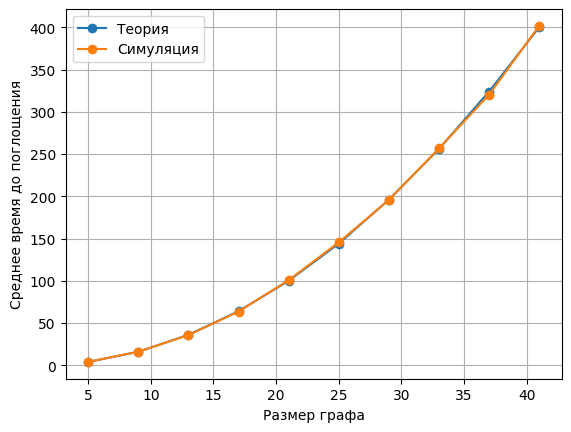

In [7]:
plt.plot(
    comparison["graph_size"],
    comparison["theory"],
    marker="o",
    label="Теория"
)

plt.plot(
    comparison["graph_size"],
    comparison["simulation"],
    marker="o",
    label="Симуляция"
)

plt.xlabel("Размер графа")
plt.ylabel("Среднее время до поглощения")
plt.legend()
plt.grid()
plt.savefig(
    "../plots/size_experiment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()